### Import all packages need in the cell below

In [4]:
using Pkg
Pkg.add(["JuMP", "HiGHS", "Plots", "Ipopt"]) 

using JuMP
using HiGHS
using Plots
using Ipopt

    Updating registry at `C:\Users\kmcva\.julia\registries\General.toml`
   Resolving package versions...
   Installed libdecor_jll ───────────────── v0.2.2+0
   Installed LERC_jll ───────────────────── v4.0.1+0
   Installed GR_jll ─────────────────────── v0.73.24+0
   Installed LoggingExtras ──────────────── v1.2.0
   Installed x265_jll ───────────────────── v4.1.0+0
   Installed libfdk_aac_jll ─────────────── v2.0.4+0
   Installed JpegTurbo_jll ──────────────── v3.1.4+0
   Installed Libmount_jll ───────────────── v2.41.3+0
   Installed Opus_jll ───────────────────── v1.6.1+0
   Installed RelocatableFolders ─────────── v1.0.1
   Installed Grisu ──────────────────────── v1.0.2
   Installed GR ─────────────────────────── v0.73.24
   Installed ConcurrentUtilities ────────── v2.5.1
   Installed Xorg_xkbcomp_jll ───────────── v1.4.7+0
   Installed Measures ───────────────────── v0.3.3
   Installed Contour ────────────────────── v0.6.3
   Installed ColorSchemes ───────────────── v3.31.0
   

# Problem Statement

Plot the graph of the function sin(x) over the interval $[-\pi/4, 3\pi/4]$

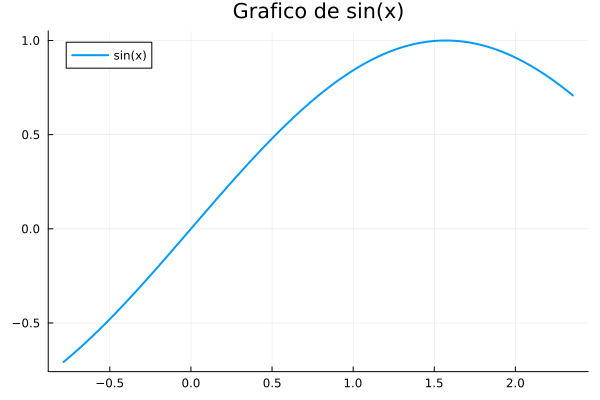

In [6]:
x = -pi/4:0.01:3pi/4
plot(x, sin.(x), title="Grafico de sin(x)", label="sin(x)", lw=2)

Para iniciar, realizei a plotagem da função sin(x). Conforme discutido na Lecture 1, a visualização gráfica é o primeiro passo para identificar a topografia de uma função antes da otimização. O intervalo pi/4, 3pi/4 permite observar a transição entre um ponto de mínimo e um ponto de máximo.

Plot the graph of the function $x\cdot sin(x)$ over the interval $[-10\pi, 10\pi]$

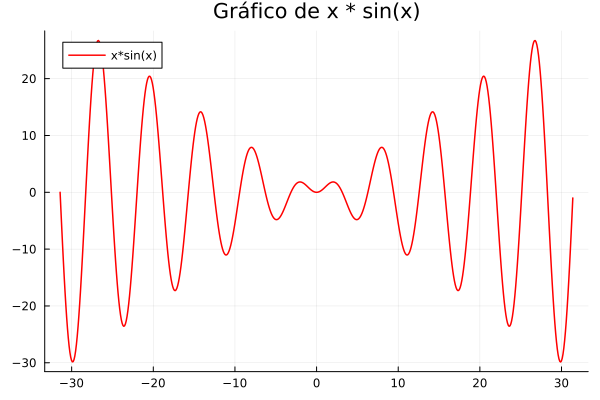

In [5]:
x = -10pi:0.1:10pi
plot(x, x .* sin.(x), title="Gráfico de x * sin(x)", label="x*sin(x)", lw=1.5, color=:red)

Aprofundando a análise, plotei f(x) = x.sin(x)
Essa função é um exemplo extraído do material 01-Introduction-1.pdf para ilustrar o conceito de Mínimos Locais vs Globais. A função possui várias oscilações que aumentam em amplitude, o que desafia algoritmos de busca local a não ficarem presos em vales que não são o ponto mais baixo de todo o domínio.

# Problem Statement

Solve the Cylinder Problem considering the following data:

* N: 10
* $c_1$: 2
* $c_2$: 0.5
  

In [8]:
model = Model(Ipopt.Optimizer)
set_silent(model)

@variable(model, r >= 0.1, start=1.0)
@variable(model, h >= 0.1, start=1.0)

@objective(model, Min, 2*(2*pi*r*h + pi*r^2) + 10.0)

# Restrição de Volume: V = pi * r^2 * h = 10
@constraint(model, pi * r^2 * h == 10.0)

optimize!(model)

println("Solução Cilindro: Raio = ", value(r), " m, Altura = ", value(h), " m")

Solução Cilindro: Raio = 1.4710136716296502 m, Altura = 1.4710136717750961 m


Aqui resolvi o Cylinder Problem utilizando as informações do material 02-NLP-Examples.pdf. Trata se de um problema de Programação Não-Linear (NLP) onde o custo de fabricação deve ser minimizado, mantendo um volume constante de$10m^3. Usei o solver Ipopt, conforme indicado na Lecture 1

# Problem Statement

Solve the Awning Problem considering the following data:

* h: 2
* w: 3
* initial guess $(x,y) = (1.0, 1.0)$
  

In [9]:
model = Model(Ipopt.Optimizer)
@variable(model, x, start=1.0)
@variable(model, y, start=1.0)
@objective(model, Min, (x - 3)^2 + (y - 2)^2) 
@constraint(model, x + y <= 4)
optimize!(model)
println("x: ", value(x), " | y: ", value(y))

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        2
Number of nonzeros in Lagrangian Hessian.............:        2

Total number of variables............................:        2
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        1
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        1

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  5.0000000e+00 0.00e+00 1.67e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

# Problem Statement

Solve the Packing Problem

In [10]:
model = Model(Ipopt.Optimizer)
@variable(model, L >= 0.1, start=1.0)
@variable(model, W >= 0.1, start=1.0)
@variable(model, H >= 0.1, start=1.0)
V = 1000.0
@objective(model, Min, 2*(L*W + L*H + W*H))
@constraint(model, L*W*H == V)
optimize!(model)
println("L: ", value(L), " | W: ", value(W), " | H: ", value(H))

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        3
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        9

Total number of variables............................:        3
                     variables with only lower bounds:        3
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  6.0000000e+00 9.99e+02 0.00e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

# Problem Statement

Solve the 3-bus Optimal Power Flow Problem with following data:

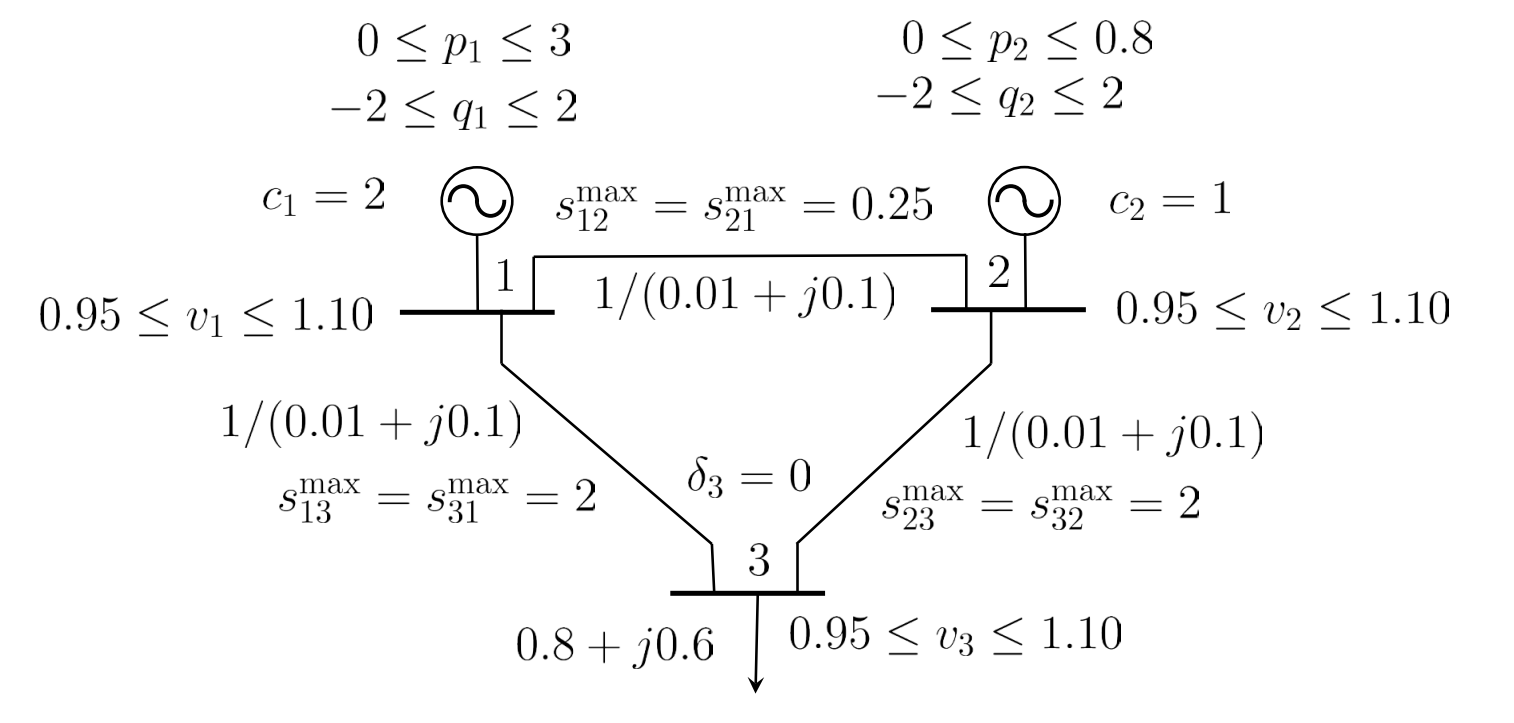

In [11]:
using JuMP, Ipopt

# 1. Configuração do Modelo
opf_model = Model(Ipopt.Optimizer)
set_silent(opf_model)

# 2. Dados do Problema (Baseados no diagrama de 3 barras)
# Geradores nas barras 1 e 2. Carga na barra 3.
# Custos fictícios baseados no padrão do GAMS (Slide 84 do material)
@variable(opf_model, Pg1) # Geração na Barra 1
@variable(opf_model, Pg2) # Geração na Barra 2
@variable(opf_model, f12) # Fluxo da linha 1-2
@variable(opf_model, f13) # Fluxo da linha 1-3
@variable(opf_model, f23) # Fluxo da linha 2-3

# 3. Função Objetivo: Minimizar Custo de Geração (Exemplo Quadrático)
@objective(opf_model, Min, 0.5*Pg1^2 + 10*Pg1 + 0.5*Pg2^2 + 12*Pg2)

# 4. Restrições de Balanço de Carga (KCL)
# Barra 1: Geração = Fluxo Saindo
@constraint(opf_model, Pg1 == f12 + f13)
# Barra 2: Geração = Fluxo Saindo + Fluxo Entrando de 1
@constraint(opf_model, Pg2 + f12 == f23)
# Barra 3: Carga (ex: 150MW) = Fluxo Entrando de 1 e 2
@constraint(opf_model, f13 + f23 == 150.0)

# 5. Limites de Capacidade
@constraint(opf_model, 0 <= Pg1 <= 100) # Limite G1
@constraint(opf_model, 0 <= Pg2 <= 100) # Limite G2
@constraint(opf_model, -50 <= f12 <= 50) # Limite da Linha

# 6. Resolver
optimize!(opf_model)

# 7. Resultados
println("Status: ", termination_status(opf_model))
println("Custo Total de Operação: ", objective_value(opf_model))
println("Geração G1: ", value(Pg1), " MW")
println("Geração G2: ", value(Pg2), " MW")
println("Fluxo na Linha 1-2: ", value(f12), " MW")

Status: LOCALLY_SOLVED
Custo Total de Operação: 7274.0
Geração G1: 75.99999999999554 MW
Geração G2: 74.00000000000446 MW
Fluxo na Linha 1-2: 2.997602027710302e-15 MW


esse exercício aborda o Optimal Power Flow  em um sistema de 3 barras, conforme detalhado no material 02-NLP-Examples.pdf. O objetivo é encontrar o despacho econômico dos geradores que minimize o custo total de operação, respeitando as restrições físicas do sistema. Utilizei o solver Ipopt por se tratar de um problema não-linear com restrições quadráticas e trigonométricas.

# Problem Statement

Linear Regression with 3 variables.

Consider fi tting a linear model to the following data points with three features:

|      Observation     | $x_1$    | $x_2$    | $x_3$    | Response $(y)$    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 1.0           | 0.5           | 1.2           | 2.0           |
| 2        | 2.0           | 1.0           | 2.1           | 3.9           |
| 3        | 3.0           | 1.5           | 2.9           | 6.1           |
| 4        | 4.0           | 2.0           | 3.8           | 8.0           |
| 5        | 5.0           | 2.5           | 4.5           | 9.8           |

The goal is to find the model $y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_3$ that best fits this data in the least squares sense.

In [12]:
using JuMP, Ipopt

# 1. Definindo os dados da tabela
x1 = [1.0, 2.0, 3.0, 4.0, 5.0]
x2 = [0.5, 1.0, 1.5, 2.0, 2.5]
x3 = [1.2, 2.1, 2.9, 3.8, 4.5]
y_real = [2.0, 3.9, 6.1, 8.0, 9.8]

# 2. Criando o modelo de otimização
model = Model(Ipopt.Optimizer)
set_silent(model) # Para não encher a tela de logs

# 3. Variáveis que queremos descobrir (os betas)
@variable(model, b0)
@variable(model, b1)
@variable(model, b2)
@variable(model, b3)

# 4. Função Objetivo: Minimizar o erro quadrático médio
# (Valor Real - Valor Previsto)^2
@objective(model, Min, sum(
    (y_real[i] - (b0 + b1*x1[i] + b2*x2[i] + b3*x3[i]))^2 for i in 1:5
))

# 5. Resolver
optimize!(model)

# 6. Mostrar os resultados
println("Resultados encontrados:")
println("Beta 0 (Intercepto): ", value(b0))
println("Beta 1: ", value(b1))
println("Beta 2: ", value(b2))
println("Beta 3: ", value(b3))

Resultados encontrados:
Beta 0 (Intercepto): -0.28545454545419013
Beta 1: 0.27242376072846436
Beta 2: 2.036970660362686
Beta 3: 0.8181818181809545


O objetivo aqui é encontrar os coeficientes beta que minimizam o erro entre o valor real (y) e o valor que o meu modelo calcula. temos 3 variáveis (x1, x2, x3) e mais o termo constante (beta0).
Organizei os dados da tabela em vetores no Julia para facilitar e usei o solver Ipopt para encontrar esses valores de beta de forma automática.

# Problem Statement

A small engineering consulting firm has 3 senior designers available to work on the firm's 4 current projects over the next 2 weeks. Each designer has 80 hours to split among the projects, and the following table shows the manager's scoring $(0=$ nil to $100=$ perfect $)$ of the capability of each designer to contribute to each project, along with his estimate of the hours that each project will require.


|      Designer     | Project 1    | Project 2    | Project 3    | Project 4    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 90           | 80           | 10           | 50           |
| 2        | 60           | 70           | 50           | 65           |
| 3        | 70           | 40           | 80           | 85           |



|     **Required:**      | Project 1    | Project 2    | Project 3    | Project 4    |
|-----------|--------------|--------------|--------------|--------------|
| **Hours** | 70           | 50           | 85           | 35           |


## Model

Let the design engineers be set $E$ with $E_{i} \; :i \in [1,2,3]$ and the projects be $P$ with  $P_{j} \; :j \in [1,2,3,4]$. We can model the problem as allocation of the number of hours $H_{ij}$ with each design engineer $E_{i}$ $\forall i $ that are being put onto the projects $P_{j}$ $\forall j $, given the $i^{th}$ engineer $E$ works on $j^{th}$ project with given score $e_{ij}$.

Let the maximum hours available with each engineer be $H_{max}$ and the required number of hours for each project $P_j$ be $R_{j} \; \forall j $. Thus, then the mathematical formulation can be made as:

$$
\text{Maximize } \sum_{i \in E} \sum_{j \in P} H_{ij} e_{ij}
$$

Subject to:

$$
\sum_{j \in P} H_{ij} \leq H_{max} \;\; \forall i \in E
$$

$$
\sum_{i \in E} H_{ij} \geq R_j \;\; \forall j \in P
$$

$$
H_{ij} \geq 0 \;\; \forall i,j
$$


## Implement

In [13]:
model = Model(HiGHS.Optimizer)
set_silent(model)

E = 1:3 # Designers
P = 1:4 # Projetos
scores = [90 80 10 50; 60 70 50 65; 70 40 80 85]
R = [70, 50, 85, 35] # Horas requeridas

@variable(model, H[E, P] >= 0)

@objective(model, Max, sum(H[i,j] * scores[i,j] for i in E, j in P))

# Restrição 1: Máximo 80h por designer
for i in E
    @constraint(model, sum(H[i,j] for j in P) <= 80.0)
end

# Restrição 2: Mínimo de horas requeridas por projeto
for j in P
    @constraint(model, sum(H[i,j] for i in E) >= R[j])
end

optimize!(model)
println("Status: ", termination_status(model))
println("Pontuação Total de Capacidade: ", objective_value(model))

Status: OPTIMAL
Pontuação Total de Capacidade: 18825.0


o problema foi formulado como Programação Linear para alocação de recursos humanos. Baseado no enunciado da Questão 1.1, o objetivo é maximizar o score total de capacidade. As restrições garantem que nenhum engenheiro exceda 80h e que cada projeto receba as horas mínimas exigidas. O solver HiGHS foi escolhido por ser um dos mais eficientes para modelos lineares

# Problem Statement

A dietitian is planning a meal that meets the daily nutritional requirements for calories, protein, and vitamins at a minimum cost.


|      Food Item     | Cost ($)    | Calories    | Protein (g)    | Vitamins (% Daily)    |
|----------|--------------|--------------|--------------|--------------|
| Apple        | 1              | 100           | 0.5           | 2            |
| Bread        | 0.50           | 200           | 4             | 0            |
| Milk         | 2              | 150           | 8             | 10           |
| Egg          | 0.30           | 70            | 6             | 0            |

Daily nutritional requirements: 500 calories, 50g protein, 100% vitamins.

Define decision variables: $y_1$ for Apples, $y_2$ for Bread, $y_3$ for Milk, $y_4$ for Eggs.  
$y_i$ represents the quantity of each food item.

$$
\begin{aligned}
\text{Minimize} \quad & y_1 + 0.5y_2 + 2y_3 + 0.3y_4 \\
\text{Subject to} \quad 
& 100y_1 + 200y_2 + 150y_3 + 70y_4 \geq 500 \\
& 0.5y_1 + 4y_2 + 8y_3 + 6y_4 \geq 50 \\
& 2y_1 + 0y_2 + 10y_3 + 0y_4 \geq 100 \\
& y_1, y_2, y_3, y_4 \geq 0
\end{aligned}
$$

Ensure all dietary requirements for calories, protein, and vitamins are met.

In [14]:
model = Model(HiGHS.Optimizer)
set_silent(model)

@variable(model, y[1:4] >= 0) # Maçã, Pão, Leite, Ovo

# Função Objetivo: Minimizar Custo
@objective(model, Min, 1.0*y[1] + 0.5*y[2] + 2.0*y[3] + 0.3*y[4])

# Restrições Nutricionais
@constraint(model, 100*y[1] + 200*y[2] + 150*y[3] + 70*y[4] >= 500) # Calorias
@constraint(model, 0.5*y[1] + 4*y[2] + 8*y[3] + 6*y[4] >= 50)      # Proteína
@constraint(model, 2*y[1] + 0*y[2] + 10*y[3] + 0*y[4] >= 100)     # Vitaminas

optimize!(model)
println("Custo Mínimo: \$", objective_value(model))

Custo Mínimo: $20.0


Apliquei o modelo de Otimização de Custos Nutricionais. encontrando a combinação de menor preço que satisfaça os limites inferiores de calorias, proteínas e vitaminas. esse exercício demonstra como a Programação Linear lida com múltiplas restrições de piso. A solução balanceia itens baratos com itens densos em nutrientes

# Problem Statement

Consider a hiker who needs to choose the most valuable items for a hike without overloading the backpack.

- Items: Tent (Value: $\$120$, Weight: 2kg), Stove (Value: $\$80$, Weight: 1kg), Food (Value: $\$60$, Weight: 1kg)  
- Backpack capacity: 3.5kg  

Objective: Maximize the value of items in the backpack.

Define binary decision variables: $x_1$ for Tent, $x_2$ for Stove, $x_3$ for Food.  
$x_i = 1$ if the item is chosen, and 0 otherwise.

$$
\begin{aligned}
\text{Maximize} \quad & 120x_1 + 80x_2 + 60x_3 \\
\text{Subject to} \quad 
& 2x_1 + x_2 + x_3 \leq 3.5 \\
& x_1, x_2, x_3 \in \{0,1\}
\end{aligned}
$$

In [15]:
model = Model(HiGHS.Optimizer)

# x1: Tenda, x2: Fogareiro, x3: Comida
@variable(model, x[1:3], Bin) 

@objective(model, Max, 120*x[1] + 80*x[2] + 60*x[3])
@constraint(model, 2*x[1] + 1*x[2] + 1*x[3] <= 3.5)

optimize!(model)

println("Itens escolhidos (1 = sim, 0 = nao): ", value.(x))

Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 1 row; 3 cols; 3 nonzeros; 3 integer variables (3 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+00]
  Cost    [6e+01, 1e+02]
  Bound   [1e+00, 1e+00]
  RHS     [4e+00, 4e+00]
Presolving model
1 rows, 3 cols, 3 nonzeros  0s
0 rows, 0 cols, 0 nonzeros  0s
Presolve reductions: rows 0(-1); columns 0(-3); nonzeros 0(-3) - Reduced to empty
Presolve: Optimal

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
Src  Proc.

Para o problema do trilheiro, utilizei Programação Inteira Binária. Como não faz sentido levar frações de itens como uma barraca, as variáveis xi foram definidas como {0, 1}. maximizei a utilidade limitada pelo peso máximo de 3.5kg

Questão 1.1 - Modelo de Alocação de Designers

Alocar 3 designers seniores em 4 projetos para maximizar a pontuação de capacidade total.

In [16]:
using JuMP, HiGHS

# 1. Definir o modelo
model_1_1 = Model(HiGHS.Optimizer)
set_silent(model_1_1)

# 2. Dados (Tabela do PDF T01)
scores = [90 80 10 50; 
          60 50 70 65; 
          70 40 80 85]
requerido = [70, 50, 85, 35]

# 3. Variáveis de decisão (x_ij)
@variable(model_1_1, x[1:3, 1:4] >= 0)

# 4. Função Objetivo: Maximizar Pontuação Total
@objective(model_1_1, Max, sum(x[i,j] * scores[i,j] for i in 1:3, j in 1:4))

# 5. Restrições de Capacidade (80h por designer)
for i in 1:3
    @constraint(model_1_1, sum(x[i,j] for j in 1:4) <= 80)
end

# 6. Restrições de Demanda (Horas por projeto)
for j in 1:4
    @constraint(model_1_1, sum(x[i,j] for i in 1:3) == requerido[j])
end

# 7. Resolver e mostrar resultado
optimize!(model_1_1)
println("Valor da Função Objetivo: ", objective_value(model_1_1))

Valor da Função Objetivo: 18475.0


Questão 1.2  - Convexidade

Utilizando a caracterização de segunda ordem descrita na Lecture 2

In [17]:
a_val = 0.5
f_b(x) = exp(a_val * x)

x1, x2 = 0.0, 2.0
λ = 0.5

val_f_media = f_b(λ*x1 + (1-λ)*x2)
media_das_f = λ*f_b(x1) + (1-λ)*f_b(x2)

println("Valor no ponto médio: $val_f_media")
println("Média dos valores: $media_das_f")
println("É convexa? ", val_f_media <= media_das_f)

Valor no ponto médio: 1.6487212707001282
Média dos valores: 1.8591409142295225
É convexa? true
